# Indicadores Econômicos do Brasil
## Projeto G1 — Tema 17
### Aluna: Lorrane Goulart  
### Professor: Alexandre Neves Louzada  
### Disciplina: Linguagens de Programação  

### Introdução e contextualização
O projeto investiga a evolução trimestral de PIB, inflação, juros, desemprego, câmbio, renda e consumo entre 2015 e 2024. O objetivo é identificar padrões, comparar indicadores e comunicar resultados em um dashboard.

**Fonte:** CSV simulado fornecido na atividade. Não são dados oficiais. As relações observadas são exercícios descritivos, sem inferência causal sobre o Brasil real. O documento tem título G2, mas esta entrega usa G1 conforme a orientação da atividade.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
ROOT = Path.cwd() if (Path.cwd() / 'analise.py').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from analise import preparar, persistir, conclusao, LABELS, NUM, CSV
sns.set_theme(style='whitegrid', palette='deep')
raw = pd.read_csv(CSV)
display(raw.head())
print('Dimensões:', raw.shape)

Dimensões: (40, 14)


,ano,trimestre,data,pib,inflacao,taxa_juros,taxa_desemprego,cambio_dolar,renda_media,consumo_familias,investimento,exportacoes,importacoes,nivel_economico
0,2015,1,2015-03-01,2013242.64,7.29,10.81,5.21,5.82,3077.70,92.81,93.19,486.01,180.73,Crise
1,2015,2,2015-06-01,1825371.98,6.97,7.76,9.32,4.41,4081.32,114.84,106.41,368.69,352.33,Crise
2,2015,3,2015-09-01,2584505.76,4.80,3.41,8.47,5.29,3510.61,132.22,121.50,492.67,292.00,Estabilidade
3,2015,4,2015-12-01,2501214.10,9.74,5.50,11.24,5.06,3987.57,96.94,110.15,438.43,395.98,Crise
4,2016,1,2016-03-01,1848504.55,3.01,7.79,10.33,5.60,3980.34,118.20,126.46,197.97,273.79,Crescimento


### Explicação da base
Cada linha representa um trimestre. As colunas ano, trimestre e data identificam o período. Nível econômico é uma categoria atribuída pela simulação. Há 10 indicadores numéricos. PIB e comércio exterior não têm escala monetária explicitada, por isso são apresentados na unidade da base. Inflação e juros não têm convenção de acumulação detalhada. Renda não é deflacionada.

In [2]:
display(pd.DataFrame({'coluna':NUM,'descrição':[LABELS[x] for x in NUM]}))
display(raw.dtypes.to_frame('tipo'))

,coluna,descrição
0,pib,PIB (unidade da base)
1,inflacao,Inflação (%)
2,taxa_juros,Juros (%)
3,taxa_desemprego,Desemprego (%)
4,cambio_dolar,Câmbio (R$/US$)
5,renda_media,Renda média (R$)
6,consumo_familias,Consumo (índice)
7,investimento,Investimento (índice)
8,exportacoes,Exportações (unidade da base)
9,importacoes,Importações (unidade da base)


,tipo
ano,int64
trimestre,int64
data,object
pib,float64
inflacao,float64
taxa_juros,float64
taxa_desemprego,float64
cambio_dolar,float64
renda_media,float64
consumo_familias,float64


### Limpeza e preparação
Converto datas e números, retiro espaços das categorias, removo duplicatas exatas e linhas inválidas e verifico a compatibilidade entre ano, trimestre e data. Conflitos de valores no mesmo trimestre são rejeitados. Ausências não são imputadas e valores extremos válidos são preservados para evitar distorção da simulação. O relatório abaixo registra o resultado real da limpeza.

In [3]:
display(raw.isna().sum().to_frame('ausências'))
df, qualidade = preparar()
display(pd.Series(qualidade, name='quantidade'))
assert len(df) == 40
assert not df.duplicated(['ano','trimestre']).any()

,ausências
ano,0
trimestre,0
data,0
pib,0
inflacao,0
taxa_juros,0
taxa_desemprego,0
cambio_dolar,0
renda_media,0
consumo_familias,0


linhas_originais              40
duplicatas_removidas           0
linhas_invalidas_removidas     0
linhas_validas                40
trimestres_ausentes            0
Name: quantidade, dtype: int64

### Engenharia de atributos
- Período: ano e trimestre em um rótulo.
- Variação trimestral do PIB: `(PIB_t / PIB_t-1 − 1) × 100`, apenas em trimestres consecutivos. O primeiro trimestre não tem taxa.
- Média móvel do PIB: quatro trimestres consecutivos; as três primeiras linhas não têm janela completa.
- Saldo comercial: exportações menos importações na escala da fonte.

As taxas são calculadas sobre toda a base antes dos filtros. A variação não é crescimento real, não é anualizada e não tem ajuste sazonal.

In [4]:
display(df[['periodo','pib','crescimento_pib_pct','pib_media_movel_4t','saldo_comercial']].head(8))

,periodo,pib,crescimento_pib_pct,pib_media_movel_4t,saldo_comercial
0,2015-T1,2013242.64,NaN,NaN,305.28
1,2015-T2,1825371.98,-9.331745,NaN,16.36
2,2015-T3,2584505.76,41.587895,NaN,200.67
3,2015-T4,2501214.10,-3.222731,2.231084e+06,42.45
4,2016-T1,1848504.55,-26.095709,2.189899e+06,-75.82
5,2016-T2,2554501.28,38.192859,2.372181e+06,241.41
6,2016-T3,2777415.79,8.726342,2.420409e+06,-219.91
7,2016-T4,1885614.95,-32.109015,2.266509e+06,-54.84


### Análise exploratória
As estatísticas resumem posição e dispersão. O CV permite comparar a dispersão relativa dos níveis, mas não é uma medida de volatilidade de retornos.

In [5]:
display(df[NUM].describe().T)
display(df.nivel_economico.value_counts().to_frame('trimestres'))
cv = (df[NUM].std()/df[NUM].mean().abs()*100).sort_values(ascending=False)
display(cv.to_frame('CV (%)'))

,count,mean,std,min,25%,50%,75%,max
pib,40.0,2.273106e+06,346694.934142,1707970.94,1.956975e+06,2287032.970,2.592124e+06,2777415.79
inflacao,40.0,6.555250e+00,2.945754,2.21,4.097500e+00,6.475,9.120000e+00,11.90
taxa_juros,40.0,9.333250e+00,3.658143,3.32,6.132500e+00,8.610,1.218500e+01,15.91
taxa_desemprego,40.0,9.284750e+00,2.979059,5.04,7.245000e+00,8.655,1.118000e+01,14.91
cambio_dolar,40.0,4.585000e+00,0.839331,3.08,3.907500e+00,4.625,5.292500e+00,5.99
renda_media,40.0,2.865280e+03,738.965589,1815.15,2.118175e+03,3038.100,3.481990e+03,4081.32
consumo_familias,40.0,1.123327e+02,17.107657,80.19,9.847500e+01,113.810,1.257200e+02,139.48
investimento,40.0,1.065965e+02,13.382967,79.49,9.522250e+01,107.970,1.162500e+02,126.46
exportacoes,40.0,3.543200e+02,93.912110,197.97,2.688200e+02,376.725,4.336450e+02,492.67
importacoes,40.0,3.052332e+02,93.952190,161.30,2.093350e+02,302.390,3.896875e+02,445.43


,trimestres
nivel_economico,
Crise,14
Crescimento,14
Estabilidade,12


,CV (%)
inflacao,44.937325
taxa_juros,39.194742
taxa_desemprego,32.085510
importacoes,30.780457
exportacoes,26.504885
renda_media,25.790345
cambio_dolar,18.306025
pib,15.252032
consumo_familias,15.229447
investimento,12.554790


### KPIs
São médias aritméticas dos trimestres. Inflação não é somada ou composta porque a convenção da fonte não foi especificada.

In [6]:
kpis = df[['pib','inflacao','taxa_desemprego','taxa_juros','cambio_dolar','crescimento_pib_pct']].mean()
display(kpis.to_frame('média'))

,média
pib,2.273106e+06
inflacao,6.555250e+00
taxa_desemprego,9.284750e+00
taxa_juros,9.333250e+00
cambio_dolar,4.585000e+00
crescimento_pib_pct,2.150193e+00


### Evolução temporal
A linha do PIB e sua média móvel ajudam a observar oscilações. Renda e câmbio são apresentados em gráficos próprios, sem misturar unidades.

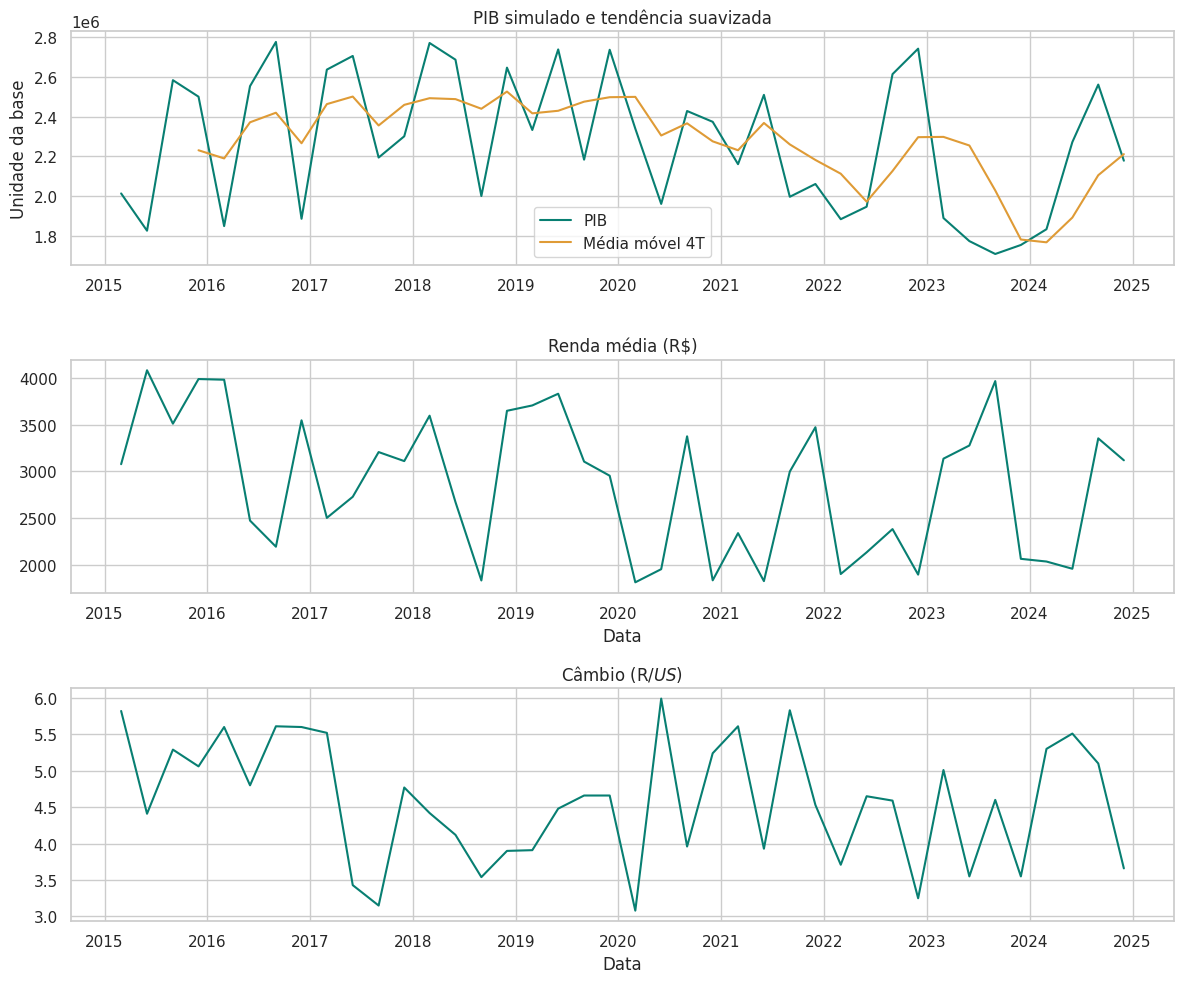

In [7]:
fig, axes = plt.subplots(3,1,figsize=(12,10))
axes[0].plot(df.data,df.pib,label='PIB',color='#087f72')
axes[0].plot(df.data,df.pib_media_movel_4t,label='Média móvel 4T',color='#df9b36')
axes[0].set_title('PIB simulado e tendência suavizada');axes[0].set_ylabel('Unidade da base');axes[0].legend()
for ax,col in zip(axes[1:],['renda_media','cambio_dolar']):
    ax.plot(df.data,df[col],color='#087f72');ax.set_title(LABELS[col]);ax.set_xlabel('Data')
fig.tight_layout();fig.savefig(ROOT/'imagens/evolucao.png',dpi=150);plt.show()

### Barras comparativas e heatmap trimestral
As barras são médias trimestrais por ano, não totais anuais do PIB.

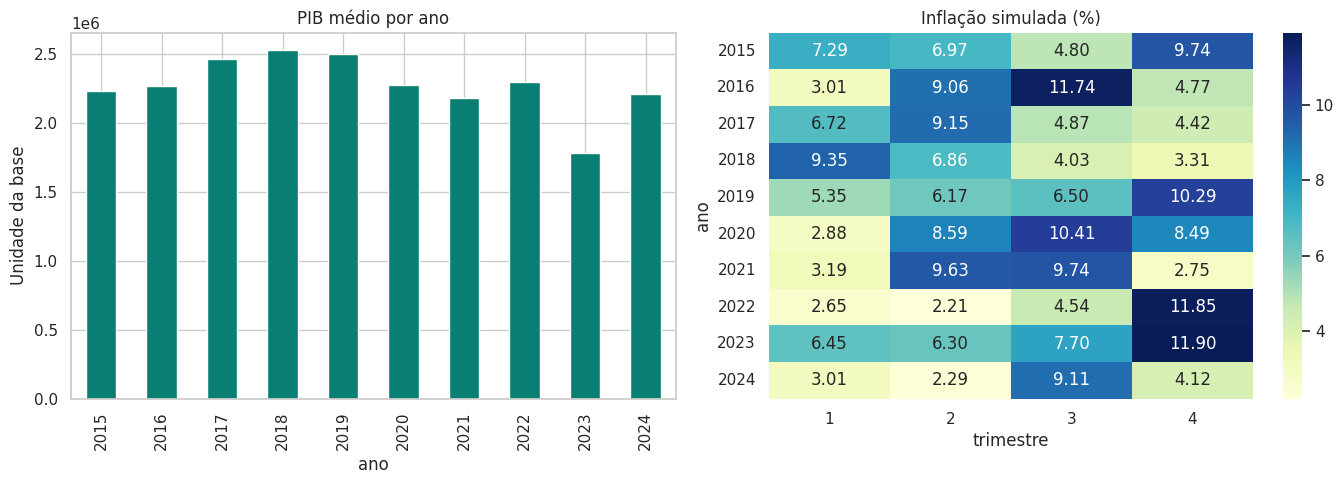

In [8]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
df.groupby('ano').pib.mean().plot.bar(ax=axes[0],color='#087f72')
axes[0].set_title('PIB médio por ano');axes[0].set_ylabel('Unidade da base')
sns.heatmap(df.pivot(index='ano',columns='trimestre',values='inflacao'),annot=True,fmt='.2f',cmap='YlGnBu',ax=axes[1])
axes[1].set_title('Inflação simulada (%)')
fig.tight_layout();fig.savefig(ROOT/'imagens/comparacao.png',dpi=150);plt.show()

### Inflação e desemprego; juros e consumo
A análise usa Pearson contemporâneo. Uma correlação positiva indica associação linear no mesmo sentido; negativa indica sentidos opostos. Não há identificação causal, controle de outras variáveis ou estimação de defasagens.

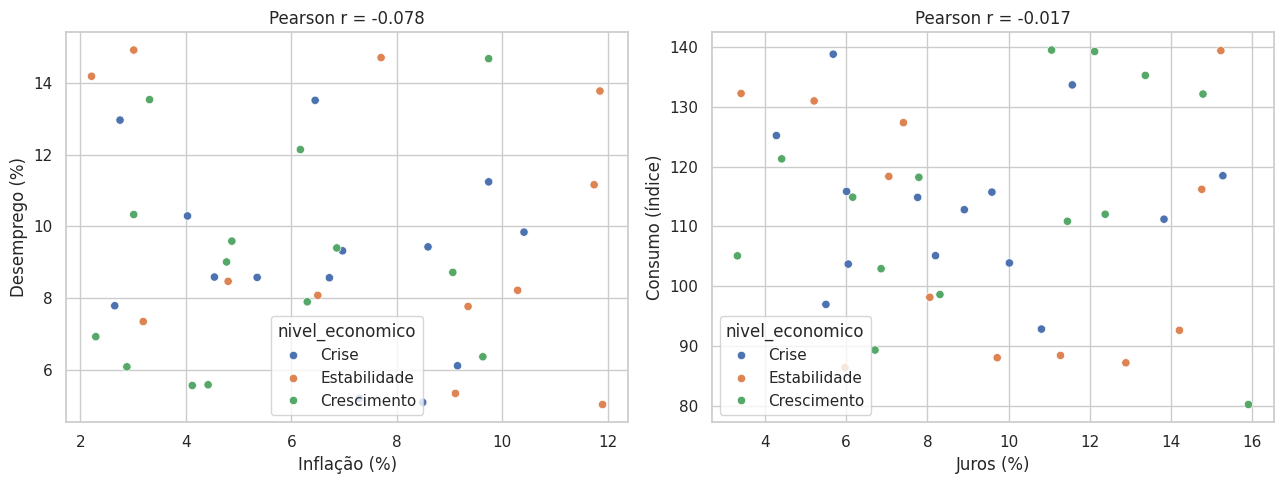

,pib,inflacao,taxa_juros,taxa_desemprego,cambio_dolar,renda_media,consumo_familias,investimento,exportacoes,importacoes
pib,1.000,0.352,-0.107,-0.151,-0.105,-0.036,-0.220,-0.014,-0.078,-0.023
inflacao,0.352,1.000,-0.283,-0.078,-0.001,-0.016,-0.134,0.034,0.062,0.057
taxa_juros,-0.107,-0.283,1.000,-0.155,0.001,-0.139,-0.017,-0.050,-0.247,0.109
taxa_desemprego,-0.151,-0.078,-0.155,1.000,0.112,0.196,-0.085,0.137,-0.059,-0.059
cambio_dolar,-0.105,-0.001,0.001,0.112,1.000,0.088,0.023,0.001,0.190,-0.108
renda_media,-0.036,-0.016,-0.139,0.196,0.088,1.000,0.120,-0.029,0.153,0.021
consumo_familias,-0.220,-0.134,-0.017,-0.085,0.023,0.120,1.000,-0.218,0.070,0.304
investimento,-0.014,0.034,-0.050,0.137,0.001,-0.029,-0.218,1.000,-0.021,-0.054
exportacoes,-0.078,0.062,-0.247,-0.059,0.190,0.153,0.070,-0.021,1.000,-0.409
importacoes,-0.023,0.057,0.109,-0.059,-0.108,0.021,0.304,-0.054,-0.409,1.000


In [9]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
for ax,(x,y) in zip(axes,[('inflacao','taxa_desemprego'),('taxa_juros','consumo_familias')]):
    sns.scatterplot(data=df,x=x,y=y,hue='nivel_economico',ax=ax)
    ax.set_xlabel(LABELS[x]);ax.set_ylabel(LABELS[y]);ax.set_title(f'Pearson r = {df[x].corr(df[y]):.3f}')
fig.tight_layout();fig.savefig(ROOT/'imagens/relacoes.png',dpi=150);plt.show()
display(df[NUM].corr().round(3))

### Radar dos indicadores
Médias normalizadas por mínimo–máximo da base completa. A normalização permite exibir escalas diferentes, mas valores maiores não significam uma economia melhor.

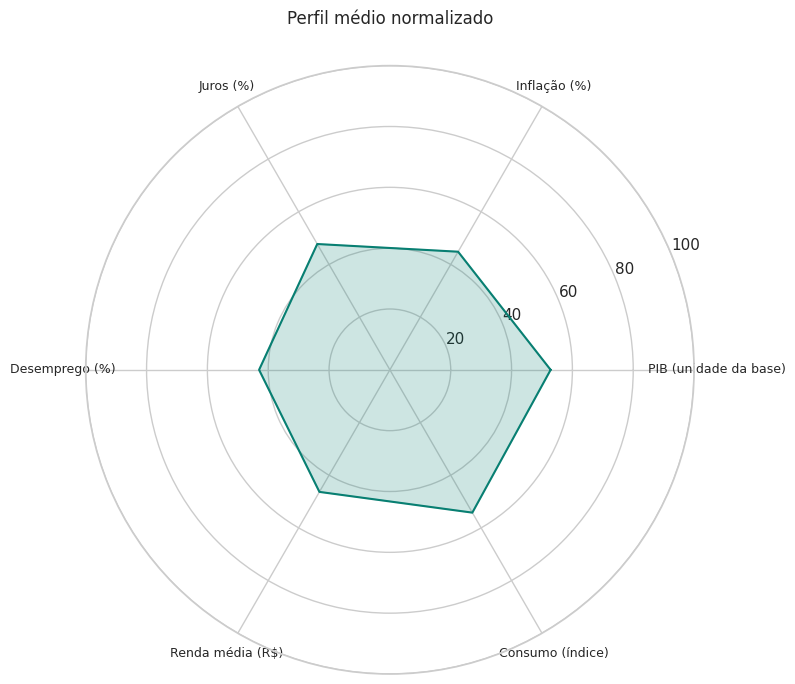

In [10]:
selecionados=['pib','inflacao','taxa_juros','taxa_desemprego','renda_media','consumo_familias']
z=(df[selecionados]-df[selecionados].min())/(df[selecionados].max()-df[selecionados].min())*100
valores=z.mean().tolist();angulos=np.linspace(0,2*np.pi,len(selecionados),endpoint=False).tolist()
fig,ax=plt.subplots(figsize=(8,7),subplot_kw={'polar':True})
ax.plot(angulos+[angulos[0]],valores+[valores[0]],color='#087f72')
ax.fill(angulos+[angulos[0]],valores+[valores[0]],alpha=.2,color='#087f72')
ax.set_xticks(angulos);ax.set_xticklabels([LABELS[x] for x in selecionados],fontsize=9);ax.set_ylim(0,100)
ax.set_title('Perfil médio normalizado',pad=30)
fig.tight_layout();fig.savefig(ROOT/'imagens/radar.png',dpi=150);plt.show()

### Tabela dinâmica e períodos críticos
O rótulo Crise vem da fonte e não é reconstruído a partir do PIB. Sua presença não demonstra uma recessão real.

In [11]:
display(df.pivot_table(index='ano',columns='nivel_economico',values='pib',aggfunc='mean'))
display(df.loc[df.nivel_economico.eq('Crise'),['periodo','pib','crescimento_pib_pct','inflacao','taxa_desemprego']])

nivel_economico,Crescimento,Crise,Estabilidade
ano,,,
2015,NaN,2.113276e+06,2584505.760
2016,2.096207e+06,NaN,2777415.790
2017,2.247962e+06,2.672268e+06,NaN
2018,2.667826e+06,2.000188e+06,2772100.600
2019,2.739617e+06,2.333365e+06,2460815.540
2020,2.340134e+06,2.254699e+06,NaN
2021,2.253437e+06,2.060946e+06,2160911.950
2022,NaN,2.249182e+06,2344940.670
2023,1.772995e+06,1.889186e+06,1730669.795


,periodo,pib,crescimento_pib_pct,inflacao,taxa_desemprego
0,2015-T1,2013242.64,NaN,7.29,5.21
1,2015-T2,1825371.98,-9.331745,6.97,9.32
3,2015-T4,2501214.10,-3.222731,9.74,11.24
8,2017-T1,2637819.42,39.891732,6.72,8.57
9,2017-T2,2706716.68,2.611902,9.15,6.12
14,2018-T3,2000188.37,-25.584712,4.03,10.29
16,2019-T1,2333365.09,-11.874629,5.35,8.58
21,2020-T2,1960499.88,-16.222743,8.59,9.43
22,2020-T3,2429037.81,23.898901,10.41,9.84
23,2020-T4,2374558.15,-2.242849,8.49,5.10


### Integração com banco de dados
SQLAlchemy grava a tabela tratada em SQLite; uma consulta SQL calcula médias anuais. A chave única ano–trimestre protege a granularidade.

In [12]:
resumo_sql = persistir(df)
display(resumo_sql)
assert resumo_sql.trimestres.sum() == len(df)

,ano,trimestres,pib_medio,inflacao_media
0,2015,4,2.231084e+06,7.2000
1,2016,4,2.266509e+06,7.1450
2,2017,4,2.460115e+06,6.2900
3,2018,4,2.526985e+06,5.8875
4,2019,4,2.498653e+06,7.0775
5,2020,4,2.276057e+06,7.5925
6,2021,4,2.182183e+06,6.3275
7,2022,4,2.297061e+06,5.3125
8,2023,4,1.780880e+06,8.0875
9,2024,4,2.211537e+06,4.6325


### Interpretação dos resultados e respostas orientadoras

In [13]:
primeiro,ultimo=df.iloc[0],df.iloc[-1]
pico=df.loc[df.crescimento_pib_pct.idxmax()]
print(f'PIB: {primeiro.pib:,.2f} → {ultimo.pib:,.2f}; variação entre extremos: {(ultimo.pib/primeiro.pib-1)*100:.2f}%.')
print(f'Maior crescimento trimestral: {pico.periodo}, {pico.crescimento_pib_pct:.2f}%.')
print(f'Renda média: {primeiro.renda_media:.2f} → {ultimo.renda_media:.2f}; variação: {(ultimo.renda_media/primeiro.renda_media-1)*100:.2f}%, sem ajuste por inflação.')
print(f'Câmbio: mínimo {df.cambio_dolar.min():.2f}; máximo {df.cambio_dolar.max():.2f} R$/US$.')
print(conclusao(df))

PIB: 2,013,242.64 → 2,178,470.79; variação entre extremos: 8.21%.
Maior crescimento trimestral: 2015-T3, 41.59%.
Renda média: 3077.70 → 3119.16; variação: 1.35%, sem ajuste por inflação.
Câmbio: mínimo 3.08; máximo 5.99 R$/US$.
No recorte de 40 trimestres, o maior PIB ocorre em 2016-T3. A correlação inflação–desemprego é -0.08 e juros–consumo é -0.02. O maior coeficiente de variação dos níveis é de Inflação (%). Há 14 registros rotulados como Crise pela fonte. Essas associações não demonstram causalidade. A base é simulada, os rótulos não equivalem a uma classificação oficial de recessão e não permitem diagnosticar a economia brasileira real.


### Conclusão
A aplicação integra preparação reproduzível, indicadores dinâmicos, visualizações comparativas e persistência. A base apresenta oscilações entre trimestres e associações que podem ser exploradas pelo dashboard. As respostas numéricas acima são derivadas diretamente do CSV.

A interpretação se limita à simulação: o tamanho reduzido, a ausência de documentação completa das unidades e a falta de controles impedem conclusões causais, projeções ou afirmações sobre crises reais. Um desdobramento seria substituir a fonte por séries oficiais com metadados e deflatores, mantendo a separação entre dados observados e simulados.